In [1]:
from lpspline import cs, bs, f, l
import polars as pl
from lpspline.viz import plot_diagnostic
import matplotlib.pyplot as plt

In [2]:
url = "https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/price/daprice.parquet"
price = pl.read_parquet(url)

url = ["https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2018.parquet",
"https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2019.parquet",
"https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2020.parquet",
"https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2021.parquet",
#"https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2022.parquet",
"https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2023.parquet",
"https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2024.parquet"]
weather = pl.scan_parquet(url).with_columns(
    s100 = (pl.col('u100')**2 + pl.col('v100')**2).sqrt(),
    time = pl.col('time').dt.cast_time_unit('ms').dt.replace_time_zone('UTC')
).select('time', 's100').group_by('time').agg(pl.col('s100').mean()).collect().sort('time')

In [3]:
df = price.join(weather, on='time')

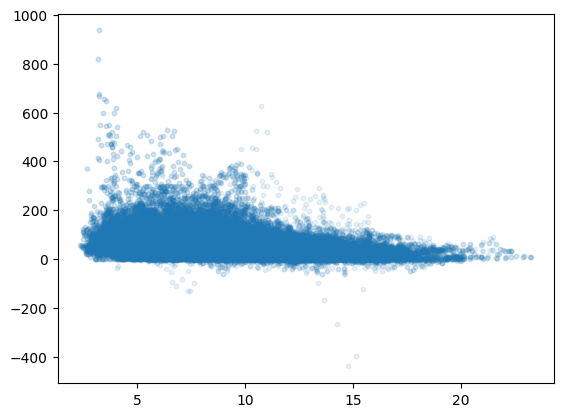

In [4]:
plt.scatter(df['s100'], df['price'], alpha=.1, s=10)

In [ ]:
ddf = df.with_columns(
    ordinal_day = pl.col('time').dt.ordinal_day(),
    hour = pl.col('time').dt.hour(),
    weekday = pl.col('time').dt.weekday(),
    year = pl.col('time').dt.year(),
)
dk1 = ddf.filter(pl.col('zone')=='DK_1')

time,price,zone,s100,ordinal_day,hour,weekday,year
"datetime[ms, UTC]",f64,str,f32,i16,i8,i8,i32
2018-01-01 00:00:00 UTC,26.43,"""DK_1""",10.307121,1,0,1,2018
2018-01-01 01:00:00 UTC,26.1,"""DK_1""",10.239222,1,1,1,2018
2018-01-01 02:00:00 UTC,24.7,"""DK_1""",10.248135,1,2,1,2018
2018-01-01 03:00:00 UTC,24.74,"""DK_1""",10.456024,1,3,1,2018
2018-01-01 04:00:00 UTC,18.01,"""DK_1""",10.797703,1,4,1,2018



✨ Model Summary ✨
Problem Status: ✅ optimal
------------------------------------------------------------------------------------------------------------------------
Spline Type          | Term         | Tag             | Constraints          | Penalties            | Params  
------------------------------------------------------------------------------------------------------------------------
🟢 CyclicSpline      | ordinal_day  | cyclicspline    | None                 | None                 | 11      
🟢 Factor            | weekday      | factor          | None                 | None                 | 7       
🟢 Factor            | year         | factor          | None                 | None                 | 6       
🟢 Linear            | s100         | linear          | None                 | None                 | 2       
------------------------------------------------------------------------------------------------------------------------
📊 Total Parameters                       

(<Figure size 1000x800 with 4 Axes>,
 array([<Axes: xlabel='ordinal_day'>, <Axes: xlabel='weekday'>,
        <Axes: xlabel='year'>, <Axes: xlabel='s100'>], dtype=object))

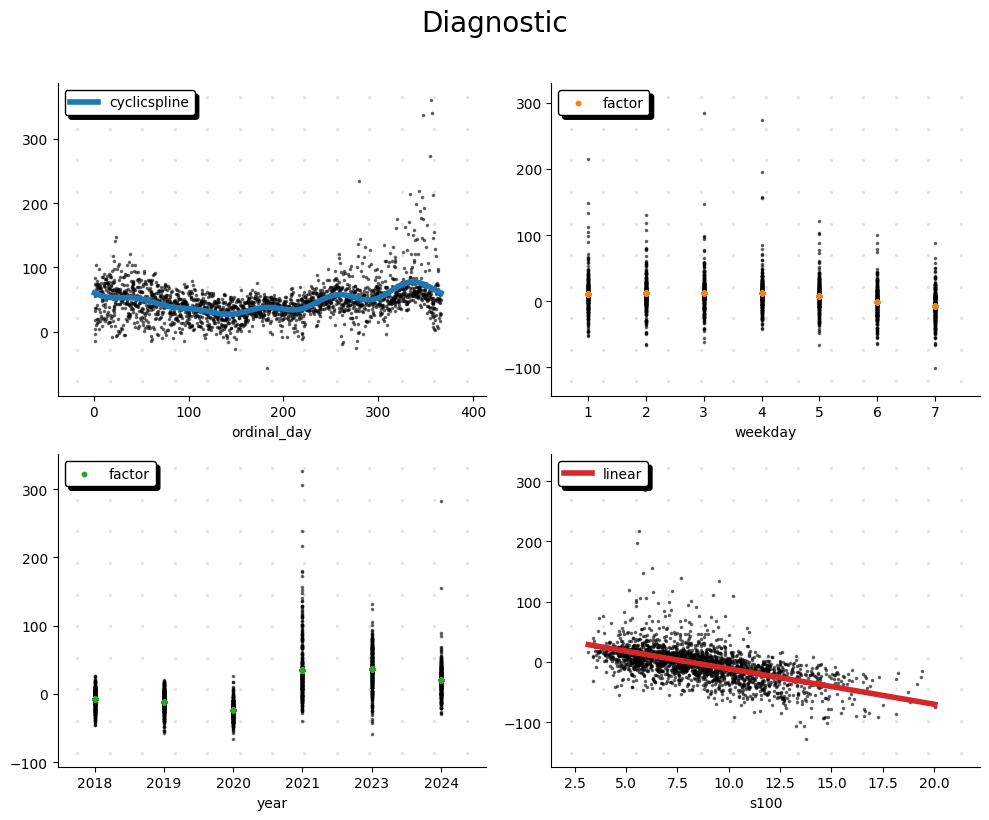

In [7]:
dk1_daily = (
    df
    .filter(pl.col('zone')=='DK_1')
    .group_by_dynamic(index_column='time', every='1d')
    .agg(pl.col('price').mean(), pl.col('s100').mean())
    .with_columns(
        ordinal_day = pl.col('time').dt.ordinal_day(),
        weekday = pl.col('time').dt.weekday(),
        year = pl.col('time').dt.year(),
        year_index = pl.col('time').dt.year() - pl.col('time').dt.year().min()
    )
)

estimatordaily = (
    +cs('ordinal_day', order=5)
    +f('weekday')
    +f('year')
    +l('s100')
)

estimatordaily.fit(X=dk1_daily, y=dk1_daily['price'])
plot_diagnostic(model=estimatordaily, X=dk1_daily, y=dk1_daily['price'], ncols=2)

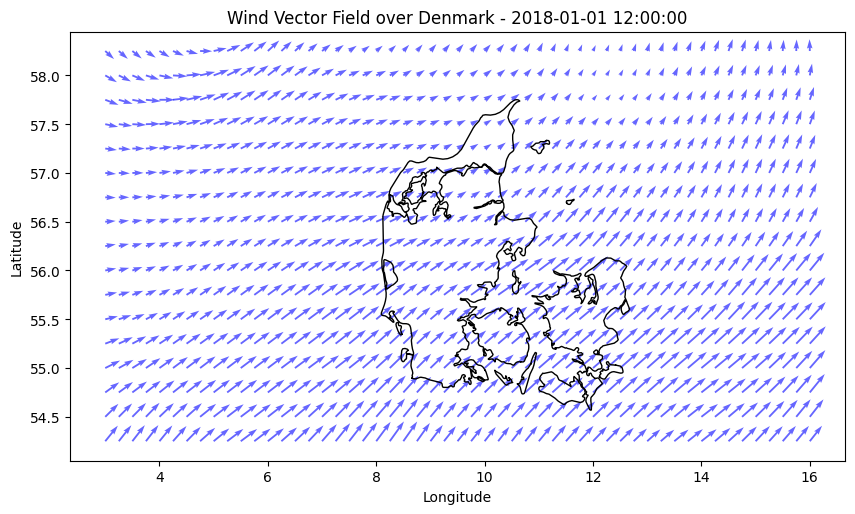

In [11]:
import json
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
import os

# 1. Load GeoJSON for Denmark directly from the virtual environment's entsoe package
geojson_files = [
    "../.venv/lib/python3.12/site-packages/entsoe/geo/geojson/DK_1.geojson",
    "../.venv/lib/python3.12/site-packages/entsoe/geo/geojson/DK_2.geojson"
]

fig, ax = plt.subplots(figsize=(10, 10))

for fpath in geojson_files:
    try:
        with open(fpath, 'r') as f:
            geo_data = json.load(f)
            for feature in geo_data.get('features', []):
                geom_type = feature['geometry']['type']
                coords = feature['geometry']['coordinates']
                if geom_type == 'Polygon':
                    for ring in coords:
                        xs, ys = zip(*ring)
                        ax.plot(xs, ys, color='black', linewidth=1)
                elif geom_type == 'MultiPolygon':
                    for poly in coords:
                        for ring in poly:
                            xs, ys = zip(*ring)
                            ax.plot(xs, ys, color='black', linewidth=1)
    except Exception as e:
        print(f"Could not load/plot {fpath}: {e}")

# 2. Load weather data for a single date
url = "https://huggingface.co/datasets/clarkmaio/dkppa/resolve/main/era5/dk_era5_2018.parquet"
value_date = "2018-01-01 12:00:00"
# Note: The notebook loads the dataset lazily, so we filter by datetime to only load the time we need
weather_snapshot = pl.scan_parquet(url).filter(
    pl.col('time').dt.cast_time_unit('ms').dt.replace_time_zone('UTC') == pl.datetime(2018, 1, 1, 12, 0, 0).dt.replace_time_zone('UTC')
).select(['latitude', 'longitude', 'u100', 'v100']).collect()

if len(weather_snapshot) > 0:
    lat = weather_snapshot['latitude'].to_numpy()
    lon = weather_snapshot['longitude'].to_numpy()
    u = weather_snapshot['u100'].to_numpy()
    v = weather_snapshot['v100'].to_numpy()
    
    q = ax.quiver(lon, lat, u, v, angles='xy', scale_units='xy', scale=50, color='blue', alpha=0.6)
    
    ax.set_title(f"Wind Vector Field over Denmark - {value_date}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    mean_lat = np.mean(lat)
    ax.set_aspect(1 / np.cos(np.radians(mean_lat)))
    
    plt.show()
else:
    print(f"No data found for {value_date}")
